In [33]:
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
import sys
sys.path.append("..")
from src.qubo_windfarm_layout.evaluation import load_layout_coordinates, get_farm_area
from src.qubo_windfarm_layout.model import get_farm_area, build_wake_loss_matrix_optimized, compute_aep_from_coords, build_qubo_from_wake_matrix_optimized
from src.qubo_windfarm_layout.visualization import plot_gurobi_refinement, plot_selected_layout
from src.solvers.utils import save_benchmark_layout

def build_local_candidates(
    gurobi_positions,
    farm_area,
    radius_m,
    step_m,
    min_distance=396.0,
):
    gurobi_positions = np.asarray(gurobi_positions, dtype=float)

    # offset locali
    offsets_1d = np.arange(
        -radius_m,
        radius_m + step_m * 0.5,
        step_m,
    )

    dx, dy = np.meshgrid(
        offsets_1d,
        offsets_1d,
        indexing="xy",
    )

    offsets = np.column_stack([
        dx.ravel(),
        dy.ravel(),
    ])

    # tengo solo punti dentro il raggio
    offsets = offsets[
        np.linalg.norm(offsets, axis=1) <= radius_m
    ]

    # genero candidati attorno a ogni turbina Gurobi
    candidate_locations = (
        gurobi_positions[:, None, :]
        + offsets[None, :, :]
    ).reshape(-1, 2)

    # aggiungo esplicitamente le posizioni Gurobi originali
    candidate_locations = np.vstack([
        candidate_locations,
        gurobi_positions,
    ])

    # tengo solo punti dentro il farm boundary
    mask = np.array([
        farm_area.covers(Point(x, y))
        for x, y in candidate_locations
    ])

    candidate_locations = candidate_locations[mask]

    # rimuovo duplicati
    candidate_locations = np.unique(
        np.round(candidate_locations, 6),
        axis=0,
    )

    # invalid pairs
    tree = cKDTree(candidate_locations)

    invalid_pairs = tree.query_pairs(
        r=min_distance,
        output_type="ndarray",
    )

    # query_pairs include anche distanza == min_distance:
    # noi vogliamo solo < min_distance
    if len(invalid_pairs) > 0:
        d = np.linalg.norm(
            candidate_locations[invalid_pairs[:, 0]]
            - candidate_locations[invalid_pairs[:, 1]],
            axis=1,
        )

        invalid_pairs = invalid_pairs[
            d < min_distance
        ]

    return (
        candidate_locations,
        invalid_pairs.astype(np.int32),
    )


import numpy as np


def build_local_wake_loss_matrix_optimized(
    candidate_locations,
    decimals=6,
):
    candidate_locations = np.asarray(
        candidate_locations,
        dtype=float,
    )

    n = len(candidate_locations)

    # 1. AEP singola turbina
    A0 = compute_aep_from_coords(
        [candidate_locations[0]]
    )

    # 2. Tutte le coppie i < j
    i_idx, j_idx = np.triu_indices(n, k=1)

    displacements = (
        candidate_locations[j_idx]
        - candidate_locations[i_idx]
    )

    # evita differenze floating tipo
    # 25.0000000001 vs 25.0
    displacements = np.round(
        displacements,
        decimals=decimals,
    )

    # 3. Canonicalizzazione:
    # (dx, dy) e (-dx, -dy) sono equivalenti
    dx = displacements[:, 0]
    dy = displacements[:, 1]

    flip = (
        (dx < 0)
        | ((dx == 0) & (dy < 0))
    )

    displacements[flip] *= -1

    # 4. Displacement unici
    unique_displacements, inverse = np.unique(
        displacements,
        axis=0,
        return_inverse=True,
    )

    print(f"Numero candidate locations: {n}")
    print(f"Numero coppie totali: {len(i_idx):,}")
    print(
        f"Numero displacement unici: "
        f"{len(unique_displacements):,}"
    )

    # 5. Physics model:
    # una sola chiamata per displacement unico
    unique_losses = np.empty(
        len(unique_displacements),
        dtype=float,
    )

    origin = np.array([0.0, 0.0])

    for k, displacement in enumerate(
        unique_displacements
    ):
        aep_pair = compute_aep_from_coords([
            origin,
            displacement,
        ])

        unique_losses[k] = max(
            0.0,
            2 * A0 - aep_pair,
        )

    # 6. Mapping verso tutte le coppie
    pair_losses = unique_losses[inverse]

    # 7. Wake-loss matrix
    L = np.zeros(
        (n, n),
        dtype=float,
    )

    L[i_idx, j_idx] = pair_losses
    L[j_idx, i_idx] = pair_losses

    return L, A0

In [26]:
GRID_RESOLUTION = 75
RADIUS = 75

gurobi_positions = load_layout_coordinates(
    "../results/layouts/gurobi_75_3600s_warmstart_None.yaml"
)

_, farm_area = get_farm_area()

candidate_locations, invalid_pairs = build_local_candidates(
    gurobi_positions=gurobi_positions,
    farm_area=farm_area,
    radius_m=RADIUS,
    step_m=GRID_RESOLUTION,
)

print(candidate_locations.shape)
print(invalid_pairs.shape)

(277, 2)
(387, 2)


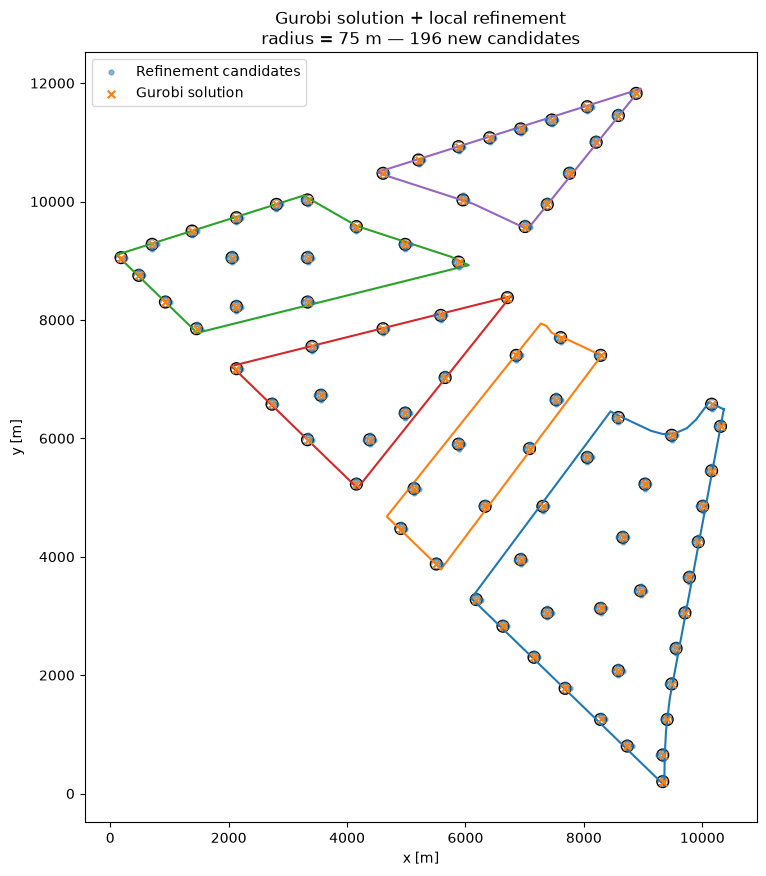

In [27]:
plot_gurobi_refinement(
    gurobi_positions=gurobi_positions,
    candidate_locations=candidate_locations,
    radius_m=RADIUS,
)

In [28]:
wake_loss_matrix, A0 = build_local_wake_loss_matrix_optimized(
    candidate_locations,
)

Numero candidate locations: 277
Numero coppie totali: 38,226
Numero displacement unici: 14,520


In [31]:
Q, offset = build_qubo_from_wake_matrix_optimized(
    wake_loss_matrix,
    invalid_pairs,
    A0,
    n_turbines=81,
    lambda_cardinality=32000,
    lambda_spacing=6500)

In [32]:
from src.solvers.sqbm import SQBMClient, solve_wflo_sqbm, solve_wflo_sqbm_qplib

SQBM_HOST = "20.229.234.199"
SQBM_PORT = 8000

client = SQBMClient(host=SQBM_HOST, port=SQBM_PORT, timeout=1200, problem_format="hdf5")

print("Health check:", client.health_check())
print("Version:     ", client.version())

Health check: True
Version:      2.1.3


n = 277 variabili, SQBM+ @ 20.229.234.199:8000 (hdf5)
Campionamento completato in 60.4s  (server: 60.0s)
Turbine selezionate: 81
Pairwise wake loss: 854511.6750


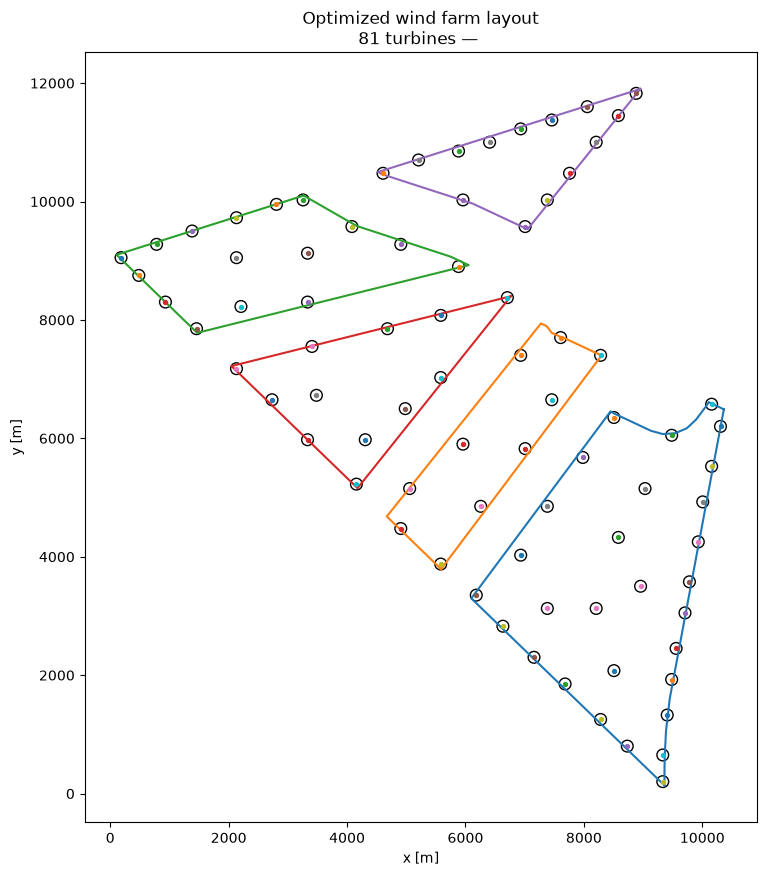

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_test_75_0algo_60s.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_test_75_0algo_60s.yaml')

In [34]:
TIMEOUT = 60
ALGO = 0

solution, sqbm_result = solve_wflo_sqbm(
    wake_loss_matrix,
    invalid_pairs,
    Q,
    host=SQBM_HOST,
    port=SQBM_PORT,
    timeout=TIMEOUT,
    algo=ALGO,
)
selected_locations_sqbm = candidate_locations[solution.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_sqbm)
save_benchmark_layout(
    selected_locations=selected_locations_sqbm,
    solver_name="sqbm",
    filename=f"sqbm_test_{GRID_RESOLUTION}_{ALGO}algo_{TIMEOUT}s.yaml",
    grid_resolution=GRID_RESOLUTION,
)